In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score, KFold, StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.neural_network import MLPClassifier

from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.metrics import confusion_matrix
from sklearn.tree import export_graphviz


import datetime
import xgboost as xgb


import numpy as np
import time
import datetime
import pydot
import os
import sys
import seaborn as sns
import matplotlib.pyplot as plt



# ĐỌC FILE CNTT_BATBUOC_DAXULY ở bước 1 tiền xử lý --> đưa vào dataframe tên là df
df = pd.read_csv('/content/drive/MyDrive/Năm 4/khoa luan/DU DOAN UNG THU PHOI/Lung Cancer Dataset.csv')

#in dữ liệu sau khi đọc từ file
print(df)

      AGE  GENDER  SMOKING  FINGER_DISCOLORATION  MENTAL_STRESS  \
0      68       1        1                     1              1   
1      81       1        1                     0              0   
2      58       1        1                     0              0   
3      44       0        1                     0              1   
4      72       0        1                     1              1   
...   ...     ...      ...                   ...            ...   
4995   32       0        1                     1              0   
4996   80       0        1                     1              1   
4997   51       1        0                     0              1   
4998   76       1        0                     1              0   
4999   33       0        1                     0              0   

      EXPOSURE_TO_POLLUTION  LONG_TERM_ILLNESS  ENERGY_LEVEL  IMMUNE_WEAKNESS  \
0                         1                  0     57.831178                0   
1                         1      

In [ ]:
#kiem tra du lieu các cột còn thiếu giá trị (đếm các cột trống có dữ liệu trống)
df.isna().sum()

,0
AGE,0
GENDER,0
SMOKING,0
FINGER_DISCOLORATION,0
MENTAL_STRESS,0
EXPOSURE_TO_POLLUTION,0
LONG_TERM_ILLNESS,0
ENERGY_LEVEL,0
IMMUNE_WEAKNESS,0
BREATHING_ISSUE,0


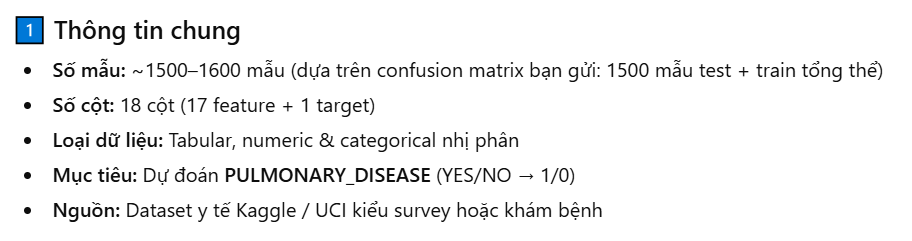

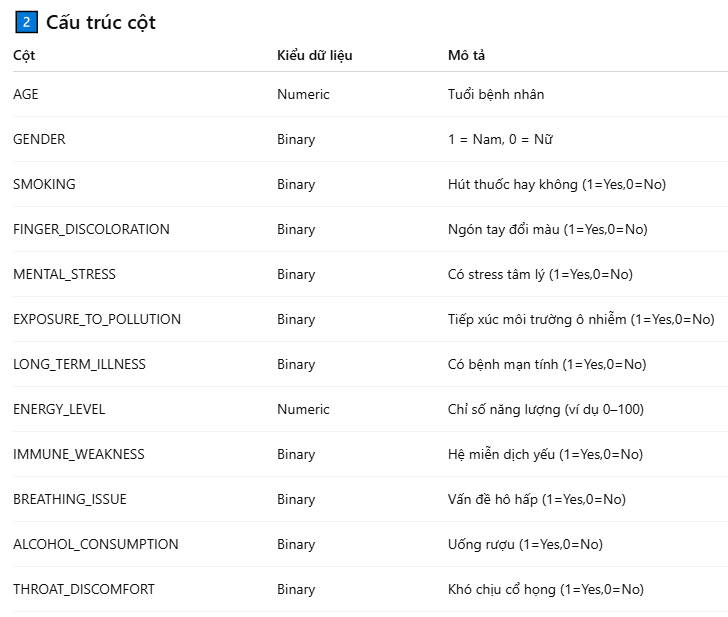

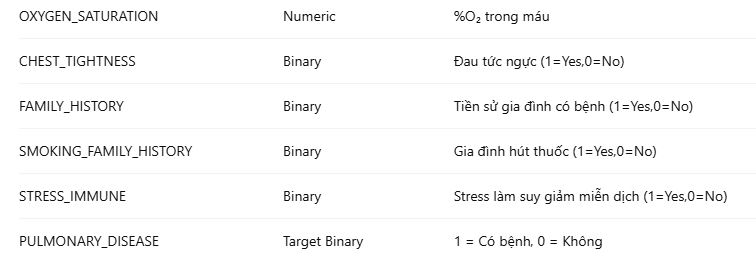

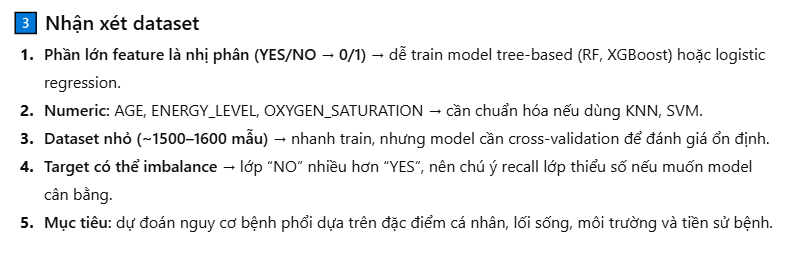

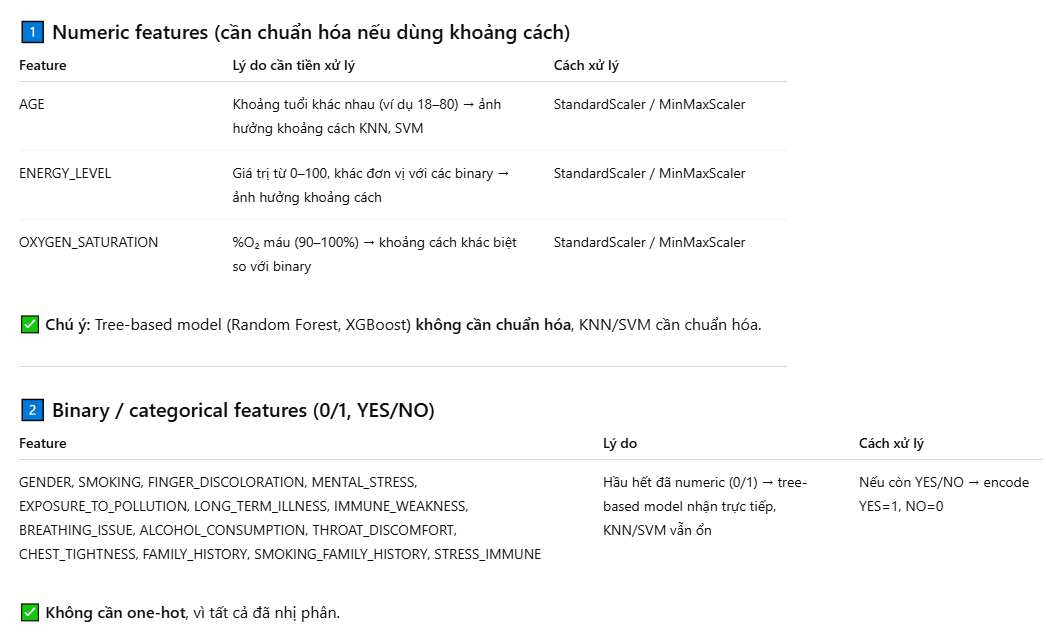

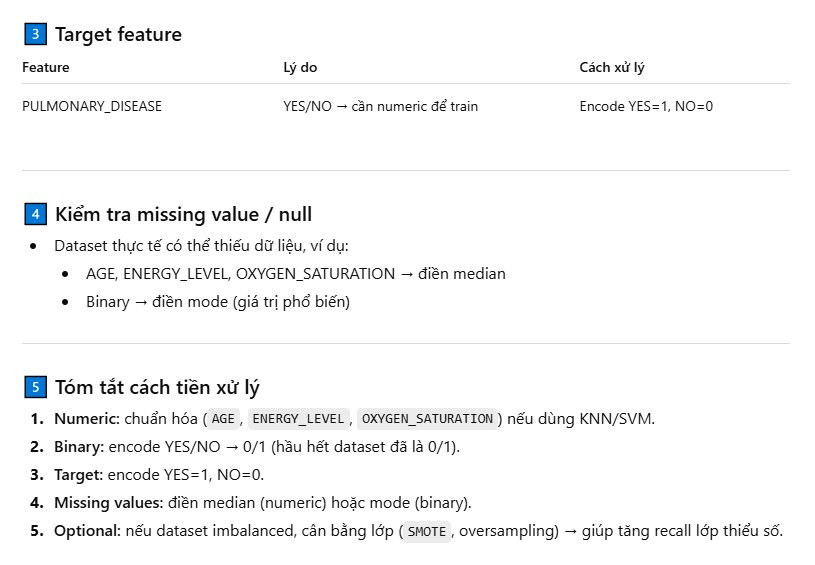

In [ ]:

# =======================================================
# Lung Cancer / Pulmonary Disease Dataset - Preprocessing & Save
# =======================================================

# df.columns.str.strip(): loại bỏ khoảng trắng đầu/cuối tên cột nếu có
df.columns = df.columns.str.strip()

print("🔹 Dataset loaded. First 5 rows:")
print(df.head())

print("\n🔹 Dataset info:")
print(df.info())

# -------------------------------
# 2️. Xử lý missing values
# -------------------------------
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype == 'object':
            df[col].fillna(df[col].mode()[0], inplace=True)
        else:
            df[col].fillna(df[col].median(), inplace=True)

print("\n🔹 Missing values handled. Nulls per column:")
print(df.isnull().sum())

# -------------------------------
# 3️. Encode target
# -------------------------------
df['PULMONARY_DISEASE'] = df['PULMONARY_DISEASE'].replace({'NO':0, 'YES':1})

# -------------------------------
# 4️. Chuẩn hóa numeric features
# -------------------------------
numeric_cols = ['AGE', 'ENERGY_LEVEL', 'OXYGEN_SATURATION']
scaler = StandardScaler()  # StandardScaler: chuẩn hóa trung bình 0, std 1
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

print("\n🔹 Numeric features standardized:")
print(df[numeric_cols].head())

# -------------------------------
# 5️. Lưu dataset đã tiền xử lý
# -------------------------------
# Lưu toàn bộ dataset đã chuẩn hóa và encode target ra CSV
# Có thể dùng trực tiếp để train model
df.to_csv("/content/drive/MyDrive/Năm 4/khoa luan/DU DOAN UNG THU PHOI/1.1.TienXuLyDuLieu/lung_cancer_preprocessed_01.csv", index=False)
print("✅ Dataset đã chuẩn hóa và lưu: lung_cancer_preprocessed_01.csv")


🔹 Dataset loaded. First 5 rows:
   AGE  GENDER  SMOKING  FINGER_DISCOLORATION  MENTAL_STRESS  \
0   68       1        1                     1              1   
1   81       1        1                     0              0   
2   58       1        1                     0              0   
3   44       0        1                     0              1   
4   72       0        1                     1              1   

   EXPOSURE_TO_POLLUTION  LONG_TERM_ILLNESS  ENERGY_LEVEL  IMMUNE_WEAKNESS  \
0                      1                  0     57.831178                0   
1                      1                  1     47.694835                1   
2                      0                  0     59.577435                0   
3                      1                  0     59.785767                0   
4                      1                  1     59.733941                0   

   BREATHING_ISSUE  ALCOHOL_CONSUMPTION  THROAT_DISCOMFORT  OXYGEN_SATURATION  \
0                0               

/tmp/ipykernel_395/1965088027.py:37: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['PULMONARY_DISEASE'] = df['PULMONARY_DISEASE'].replace({'NO':0, 'YES':1})


✅ Dataset đã chuẩn hóa và lưu: lung_cancer_preprocessed_01.csv


🔹 Số lượng từng lớp:
PULMONARY_DISEASE
0    2963
1    2037
Name: count, dtype: int64

🔹 Tỷ lệ phần trăm từng lớp:
PULMONARY_DISEASE
0    59.26
1    40.74
Name: proportion, dtype: float64


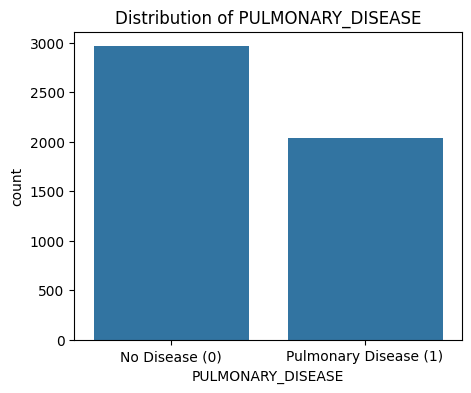

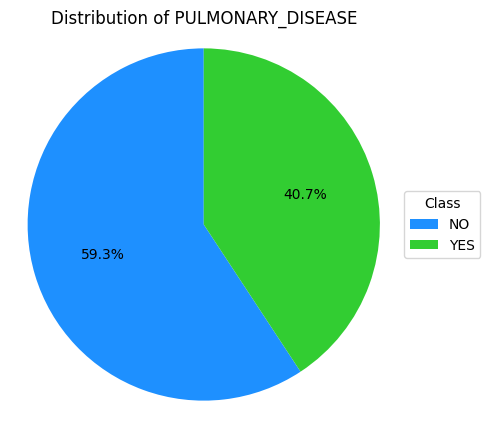

In [ ]:
# Xem số lượng mỗi lớp
counts = df['PULMONARY_DISEASE'].value_counts()
print("🔹 Số lượng từng lớp:")
print(counts)

# Xem tỷ lệ phần trăm
percentages = df['PULMONARY_DISEASE'].value_counts(normalize=True) * 100
print("\n🔹 Tỷ lệ phần trăm từng lớp:")
print(percentages)

# Optional: trực quan hóa bằng biểu đồ
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5,4))
sns.countplot(x='PULMONARY_DISEASE', data=df)
plt.title('Distribution of PULMONARY_DISEASE')
plt.xticks([0,1], ['No Disease (0)', 'Pulmonary Disease (1)'])
plt.show()

# Vẽ biểu đồ tròn
plt.figure(figsize=(5,5))

colors = ['dodgerblue', 'limegreen']

wedges, texts, autotexts = plt.pie(
    counts.values,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90
)

plt.title('Distribution of PULMONARY_DISEASE')
plt.axis('equal')

plt.legend(
    wedges,
    ['NO', 'YES'],
    title="Class",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

# Lưu hình
plt.savefig("/content/drive/MyDrive/Năm 4/khoa luan/DU DOAN UNG THU PHOI/1.1.TienXuLyDuLieu/pulmonary_disease_pie_chart.png", dpi=300, bbox_inches='tight')

plt.show()